# Conceptual Overview of ase_uhal

This notebook serves to provide a visual overview of the content included in the written theory section. Rather than present concepts at full MLIP scale, we consider building a surrogate model for a much simpler 1D potential:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import scipy
np.random.seed(42)

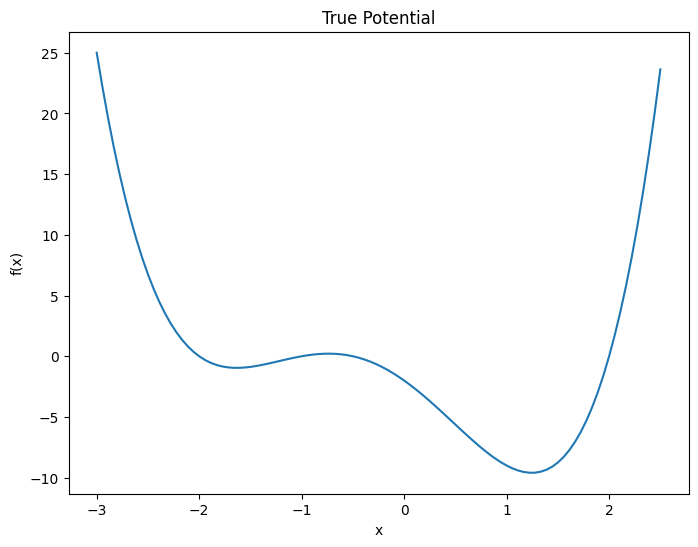

In [2]:
roots = [-2, -1, -0.5, 2]

def f(x):
    '''
    "True" potential
    '''
    return np.prod([x-root for root in roots], axis=0)

def f_grad(x):
    '''
    Gradient of the true potential
    '''

    rt = np.array(roots)
    grad = 0

    for i in range(len(roots)):
        mask = np.ones(len(roots), dtype=bool)
        mask[i] = 0
        r = rt[mask]
        grad += np.prod([x-root for root in r])
    return grad


x_ref = np.linspace(-3, 2.5, 100)

fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(x_ref, f(x_ref))

plt.ylabel("f(x)")
plt.xlabel("x")
plt.title("True Potential")
plt.show()

## Least-squares fitting of a simple model

For this example, we use a set of squared-exponential basis functions:
$$
\begin{equation}
m(x, \theta) = \sum_i \phi_i(x) \theta_i
\end{equation}
$$
$$
\begin{equation}
\phi_i = \mathrm{e}^{-\frac{(x - c_i)^2}{2l}}
\end{equation}
$$

We can fit this model using least squares, by minimising the squared difference between model and target
$$
\begin{equation}
\theta_\text{LS} = \text{min}_\theta \left(m(x, \theta) - f(x)\right)^2
\end{equation}
$$

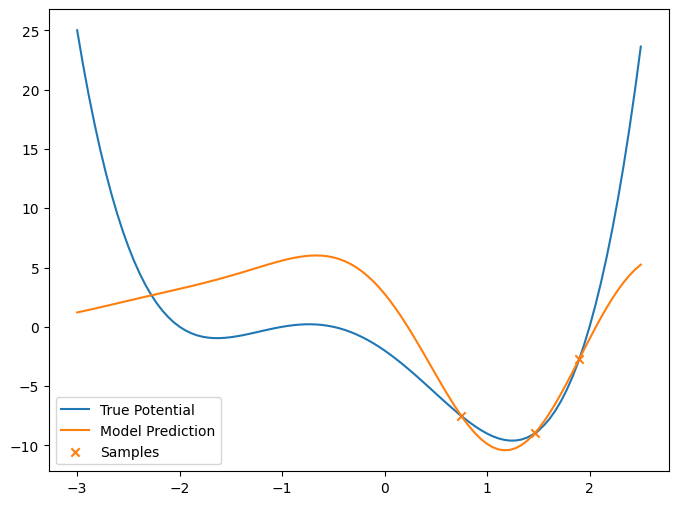

In [3]:
def phi(x, nbasis=10, l=0.5):
    '''
    Returns a vector of phi_i(x) for all i
    '''
    centers = np.linspace(-2.5, 2.5, nbasis)

    return np.array([np.exp(-(x-c)**2/(2*l)) for c in centers])

def phi_grad(x, nbasis=10, l=0.5):
    '''
    Gradient of each of the phi functions
    '''
    centers = np.linspace(-2.5, 2.5, nbasis)
    return np.array([-2 * (x-c)/l * np.exp(-(x-c)**2/(2*l)) for c in centers])

def m(x, weights, nbasis=10, l=0.5):
    '''
    Main model
    '''
    return phi(x, nbasis, l).T @ weights

def m_grad(x, weights, nbasis=10, l=0.5):
    '''
    Gradient of the model
    '''
    return phi_grad(x, nbasis, l).T @ weights

def loss(weights, x_samples, y_samples):
    '''
    Loss function, for a given set of model weights
    '''
    return np.sum((y_samples - m(x_samples, weights))**2)

# Train initial model from 3 random samples near the true minimum
x_samples = np.random.random(3) * 2
y_samples = f(x_samples)
res = minimize(loss, np.ones(10), args=(x_samples, y_samples))

w0 = res.x # Initial weights

fig, ax = plt.subplots(1, figsize=(8, 6))
plt.plot(x_ref, f(x_ref), label="True Potential")
plt.plot(x_ref, m(x_ref, w0), label="Model Prediction")
plt.scatter(x_samples, y_samples, label="Samples", color="C1", marker="x")
plt.legend()

We can see that the model fits the truth decently well in the region where there is data, but clearly the model struggles to extrapolate away from the data.

Now let's try to gather some more training data. Because this toy system is very simple, we could directly do some sampling in 1D, or run some velocity verlet using the true potential. However, in the development of MLIP models, we are typically working with much higher dimensional problems, where the ground truth (usually DFT) is significantly more expensive to compute.

Instead, we will use our surrogate model to drive verlet MD, and take every 100th iteration as a new training point.

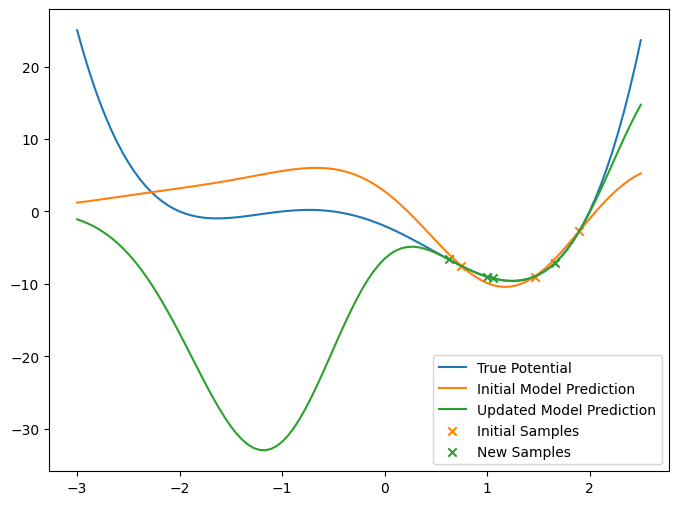

In [4]:
def verlet_step(grad_func, x, v, dt):
    a_t = - grad_func(x) # a(t)

    v_half = v + 0.5 * a_t * dt # v(t+0.5dt)
    x_new = x + v_half * dt # x(t+dt)

    a_t_plus = - grad_func(x_new) # a(t+dt)
    v_new = v_half + 0.5 * a_t_plus * dt # v(t+dt)

    return x_new, v_new

def verlet(grad_func, x0, v0, dt, nsteps):
    x = np.zeros(nsteps+1)
    v = np.zeros_like(x)

    x[0] = x0
    v[0] = v0

    for i in range(nsteps):
        x[i+1], v[i+1] = verlet_step(grad_func, x[i], v[i], dt)

    return x, v


def mg(x):
    return m_grad(x, weights=w0)
# Run verlet on the true distribution

x0 = 1.0
v0 = -4.0

x, v = verlet(mg, x0, v0, 0.01, 300)

# Choose some of the trajectory as new training data
new_x_samples = x[::100]
new_y_samples = f(new_x_samples)

# Retrain the model
x_train = np.concatenate([x_samples, new_x_samples])
y_train = np.concatenate([y_samples, new_y_samples])

res = minimize(loss, w0, args=(x_train, y_train))

w = res.x # Updated weights

fig, ax = plt.subplots(1, figsize=(8, 6))
plt.plot(x_ref, f(x_ref), label="True Potential")
plt.plot(x_ref, m(x_ref, w0), label="Initial Model Prediction")
plt.plot(x_ref, m(x_ref, w), label="Updated Model Prediction")
plt.scatter(x_samples, y_samples, label="Initial Samples", color="C1", marker="x")
plt.scatter(new_x_samples, new_y_samples, label="New Samples", color="C2", marker="x")
plt.legend()

We can see that the updated model is a closer fit to the truth than the old model, in the potential well that the MD started in. However, the MD has been unable to effectively explore the available space, and so our new model is unable to learn anything about the other minimum.

## Bayesian Regression
Instead of using a least-squares approach, we could use Bayesian regression. The main difference here is that a Bayesian treatment returns a probability distribution over the weights, known as the _posterior_ distribution, rather than just a single "best" point.

Here, we assume that any noise present on our observations follows a normal distribution with standard deviation y_err. We also assume a normal distribution with standard deviation $\alpha$ for our prior on the weights. This means that the resulting posterior distribution is also a normal distribution:
$$
\begin{equation}
\theta_\text{Bayes} \sim \mathcal{N}(\bar{\theta}, \Sigma)
\end{equation}
$$
where $\bar{\theta}$ is the mean weights for the distribution, $\Sigma$ is the covariance of the posterior distribution, and $\theta_\text{Bayes}$ is a sample of the posterior distribution. For details of the linear algebra involved in solving this posterior distribution, see https://pubs.aip.org/aip/jcp/article/159/17/174108/2919934/Gaussian-approximation-potentials-Theory-software equations 4-9.

Once we have found the posterior distribution, we can take the mean of the distribution to be our optimal model. However, we can also draw samples from the distribution to form a committee of models, which are all compatible with the training data:

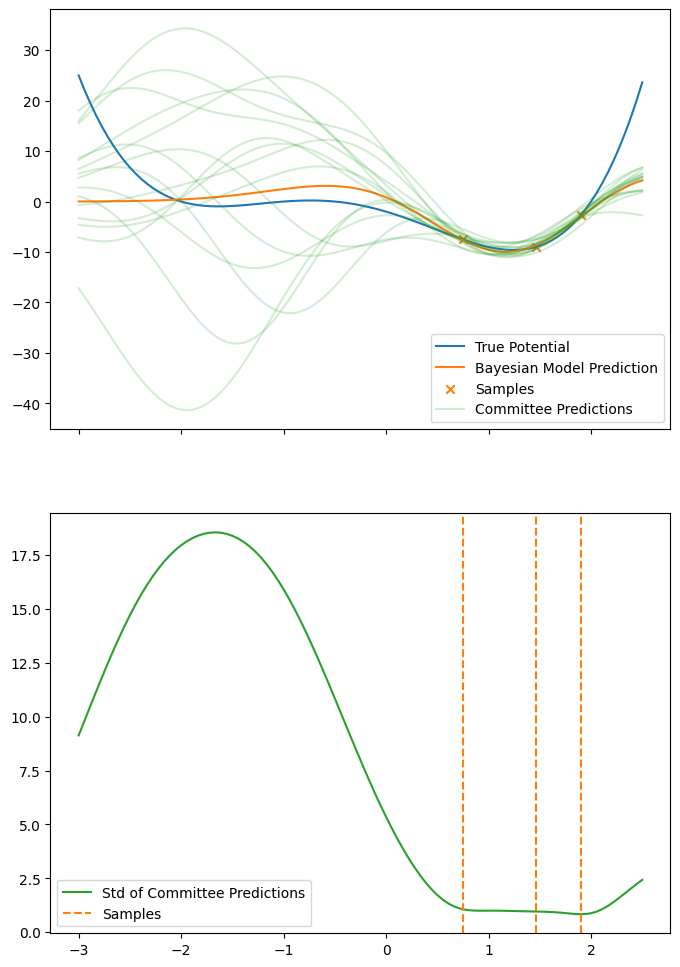

In [5]:
def make_posterior_covariance(x_samples, alpha=0.1, y_err=1, nbasis=10, l=0.5):
    N = x_samples.shape[0]

    A = np.zeros((N+nbasis, nbasis))
    A[0:N, :] = phi(x_samples, nbasis, l).T / y_err
    A[N:, :] = np.eye(nbasis) * alpha
    Q, R = np.linalg.qr(A)

    return Q, R

def solve_posterior(x_samples, y_samples, alpha=0.1, y_err=1, nbasis=10, l=0.5):
    N = x_samples.shape[0]

    Q, R = make_posterior_covariance(x_samples, alpha, y_err, nbasis, l)

    b = np.zeros(N + nbasis)
    b[:N] = y_samples

    weights = scipy.linalg.solve_triangular(R, Q.T @ b, lower=False)

    return weights, R

w0, R = solve_posterior(x_samples, y_samples)

biased_weights = w0.copy()

# Sample a committee of models
ncomm = 15
z = np.random.normal(size=(10, ncomm))
wcomm = scipy.linalg.solve_triangular(R, z, lower=False).T
for i in range(ncomm):
    wcomm[i, :] += w0

fig, ax = plt.subplots(2, figsize=(8, 12), sharex=True)
ax[0].plot(x_ref, f(x_ref), label="True Potential")
ax[0].plot(x_ref, m(x_ref, w0), label="Bayesian Model Prediction")
ax[0].scatter(x_samples, y_samples, label="Samples", color="C1", marker="x")

for i in range(ncomm-1):
    ax[0].plot(x_ref, m(x_ref, wcomm[i, :]), color="C2", alpha=0.2)
ax[0].plot(x_ref, m(x_ref, wcomm[-1, :]), color="C2", alpha=0.2, label="Committee Predictions")
ax[0].legend()


## Plot the standard deviation of the committee
def comm_std(x, comm_weights):
    ncomm = comm_weights.shape[0]
    if type(x) == np.ndarray:
        N = x.shape[0]
    else:
        N = 1
    comm_pred = np.zeros((ncomm, N))

    for i in range(ncomm):
        comm_pred[i, :] = m(x, comm_weights[i, :])

    return np.std(comm_pred, axis=0)

std = comm_std(x_ref, wcomm)

ax[1].plot(x_ref, std, color="C2", label="Std of Committee Predictions")

ax[1].axvline(x_samples[0], color="C1", linestyle="dashed", label="Samples")
for xs in x_samples[1:]:
    ax[1].axvline(xs, color="C1", linestyle="dashed")

ax[1].legend()

We can see that the committee agrees rather well in the potential well close to the training data, but that the standard deviation diverges as we get further from the training data.

In the HyperActive Learning (HAL) approach by van der Oord et. al., they use the standard deviation of a committee of ACE MLIP models to form a biasing potential, so that the biased energy $E_\text{Bias}$ is given by
$$
\begin{equation}
E_\text{Bias}(x) = E_\text{ACE}(x, \bar{\theta}) - \tau \,\text{std}_i \, E_\text{ACE}(x, \theta_i)
\end{equation}
$$
where $\tau$ is the strength of the committee biasing. The effect of this biased energy is to artificially lower the potential energy of structures where the committee strongly disagree, which makes it more likely for an MD calculation to explore spaces which are far from the training data. Applying this concept to our toy problem, we get:  

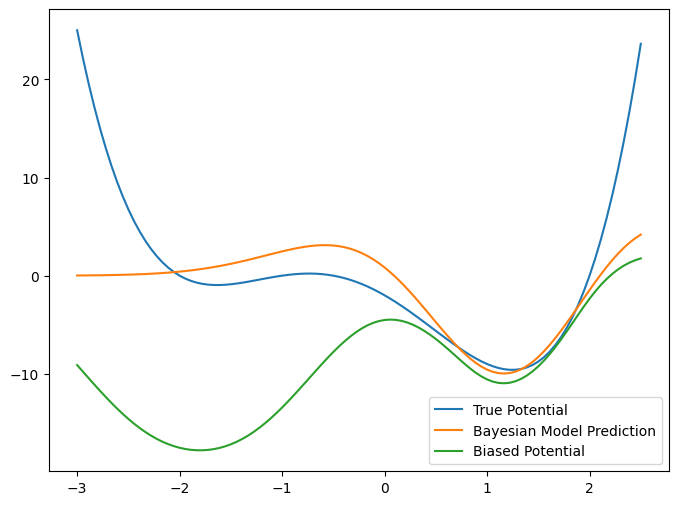

In [6]:
def m_biased(x, comm_weights, mean_weights, tau):
    std = comm_std(x, comm_weights)
    mean = m(x, mean_weights)

    return mean - tau * std

tau = 1.0

fig, ax = plt.subplots(1, figsize=(8, 6))
plt.plot(x_ref, f(x_ref), label="True Potential")
plt.plot(x_ref, m(x_ref, w0), label="Bayesian Model Prediction")
plt.plot(x_ref, m_biased(x_ref, wcomm, w0, tau), label="Biased Potential")
plt.legend()


The introduction of the biasing here has lowered the potential energy barrier between minima, and has also made the other minimum much lower in energy, since it is very far from the training data points.

To show how the biasing affects MD, lets run verlet dynamics with both approaches, and plot a histogram of the samples found in both runs.

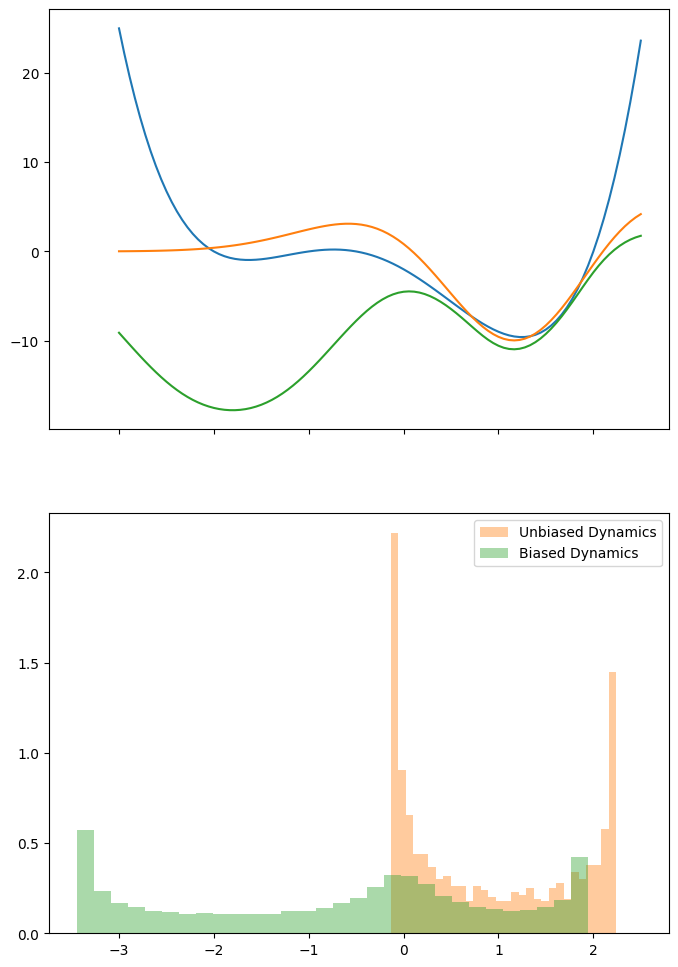

In [7]:
x0 = 0.0
v0 = -2.0
tau = 1.0

def mg_bias(x):
    m_bar = m(x, w0)
    dm_bar = m_grad(x, w0)

    N = wcomm.shape[0]
    std = comm_std(x, wcomm)

    # Biasing potental = std(m(x, w_i))
    # Derivative w.r.t. x is (1/(N std(x, w_i))) * sum_j (m(x, w_i) - m(x, w_mean)) * m_grad(x, w_i) 

    s = np.sum([(m(x, wcomm[i, :]) - m_bar) * m_grad(x, wcomm[i, :]) for i in range(N)])
    
    s /= (N * std)

    return (dm_bar - tau * s)[0]

x, v = verlet(mg, x0, v0, 0.01, 1_000)
x_bias, v_bias = verlet(mg_bias, x0, v0, 0.01, 1_000)

fig, ax = plt.subplots(2, figsize=(8, 12), sharex=True)
ax[0].plot(x_ref, f(x_ref), label="True Potential")
ax[0].plot(x_ref, m(x_ref, w0), label="Bayesian Model Prediction")
ax[0].plot(x_ref, m_biased(x_ref, wcomm, w0, tau), label="Biased Potential")

ax[1].hist(x, bins=30, density=True, label="Unbiased Dynamics", alpha=0.4, color="C1")
ax[1].hist(x_bias, bins=30, density=True, label="Biased Dynamics", alpha=0.4, color="C2")
ax[1].legend()

The biasing has clearly allowed the MD to overcome the barrier between minima, enabling sampling over a broader range of the input space x, for this choice of initial position and velocity.

Lets again draw samples from both MD trajectories to try to fit improved models:

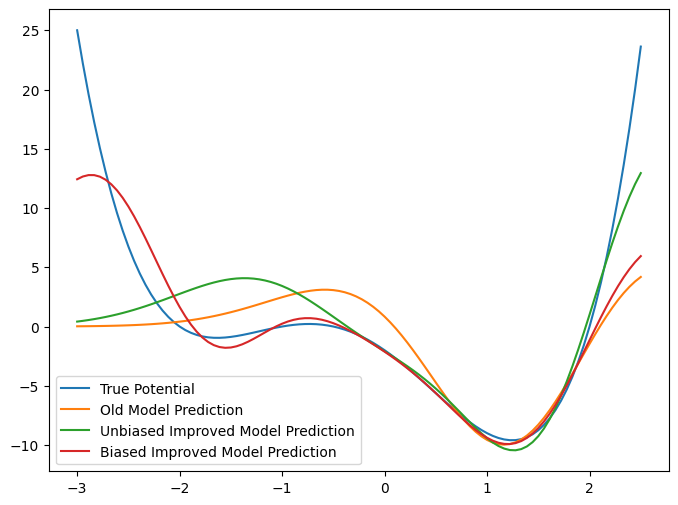

In [8]:
new_x_samples = x[::100]
new_x_samples_bias = x_bias[::100]

new_y_samples = f(new_x_samples)
new_y_samples_bias = f(new_x_samples_bias)

x_train = np.concatenate([x_samples, new_x_samples])
y_train = np.concatenate([y_samples, new_y_samples])

weights_unbiased, _ = solve_posterior(x_train, y_train)

x_train_bias = np.concatenate([x_samples, new_x_samples_bias])
y_train_bias = np.concatenate([y_samples, new_y_samples_bias])

weights_biased, R_biased = solve_posterior(x_train_bias, y_train_bias)

fig, ax = plt.subplots(1, figsize=(8, 6), sharex=True)
plt.plot(x_ref, f(x_ref), label="True Potential")
plt.plot(x_ref, m(x_ref, w0), label="Old Model Prediction")
plt.plot(x_ref, m(x_ref, weights_unbiased), label="Unbiased Improved Model Prediction")
plt.plot(x_ref, m(x_ref, weights_biased), label="Biased Improved Model Prediction")
plt.legend()


The biasing has clearly allowed the training data samples to cover a wider range of inputs, and thus the bias-improved model is a significantly better surrogate model for the true potential.

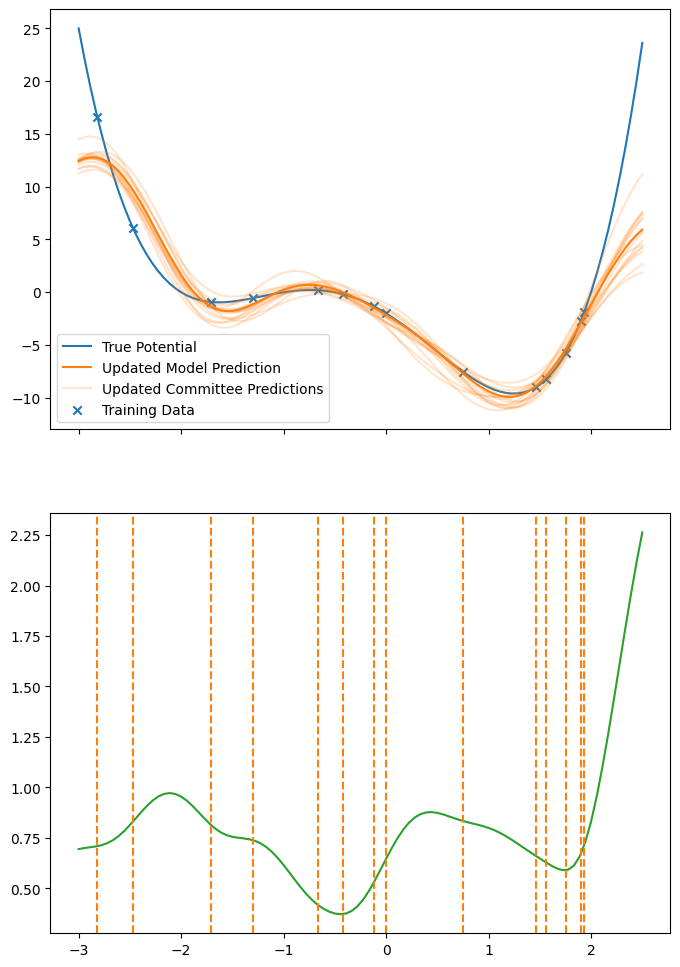

In [9]:
z = np.random.normal(size=(10, ncomm))
wcomm_biased = scipy.linalg.solve_triangular(R_biased, z, lower=False).T
for i in range(ncomm):
    wcomm_biased[i, :] += weights_biased

fig, ax = plt.subplots(2, figsize=(8, 12), sharex=True)

ax[0].plot(x_ref, f(x_ref), label="True Potential")
ax[0].plot(x_ref, m(x_ref, weights_biased), label="Updated Model Prediction")

for i in range(ncomm-1):
    ax[0].plot(x_ref, m(x_ref, wcomm_biased[i, :]), color="C1", alpha=0.2)
ax[0].plot(x_ref, m(x_ref, wcomm_biased[-1, :]), color="C1", alpha=0.2, label="Updated Committee Predictions")
ax[0].scatter(x_train_bias, y_train_bias, color="C0", label="Training Data", marker="x")
ax[0].legend()

std = comm_std(x_ref, wcomm_biased)

ax[1].plot(x_ref, std, color="C2", label="Std of Updated Committee")
ax[1].axvline(x_train_bias[0], color="C1", linestyle="dashed", label="Training Data")
for xs in x_train_bias[1:]:
    ax[1].axvline(xs, color="C1", linestyle="dashed")


We can see that the committee of this improved model is in much tighter agreement. We can see that the structure of the standard deviation has changed significantly, and thus a new error-biased potential would again more favourably explore data-sparse space.

### On-the-fly updates to the committee
One quirk of the Bayesian posterior in our case is that the posterior covariance (which defines the variance of the committee) only depends on the $\phi_i(x)$ values, not on $f(x)$ observarions. This means that we can update the biasing potential without needing to evaluate $f(x)$ - in this simple example, $f(x)$ is trivial to compute, but this is not always true (e.g. $f(x)$ could be a DFT calculation).

The limitation to this quirk is that by not including the impact of $f(x)$ observations, we cannot update the committee mean based on this new data, and therefore can't improve the quality of the underlying potential. 

Lets visually demonstrate how this quirk works, by selecting a new datapoint at $x=2.3$ and updating the posterior variance, but keeping the poterior mean the same 

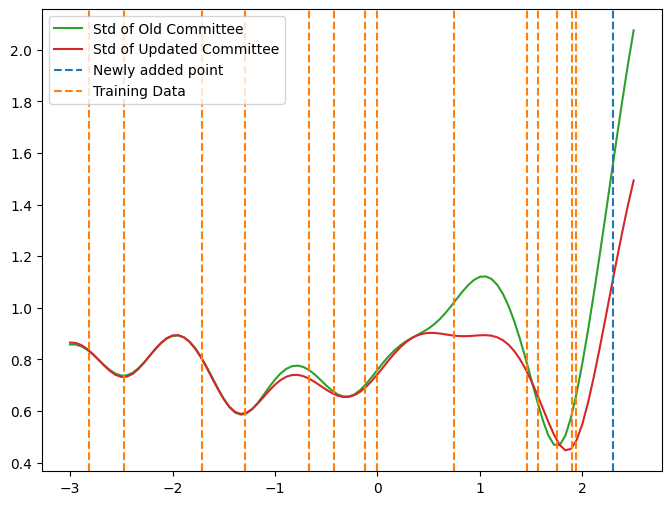

In [10]:
R_old = R_biased.copy()

new_x_point = 2.3

new_x_train = np.append(x_train_bias, new_x_point)

_, R_updated = make_posterior_covariance(new_x_train)

ncomm = 40
z = np.random.normal(size=(10, ncomm))
wcomm_old = scipy.linalg.solve_triangular(R_old, z, lower=False).T
wcomm_updated = scipy.linalg.solve_triangular(R_updated, z, lower=False).T
for i in range(ncomm):
    wcomm_old[i, :] += weights_biased
    wcomm_updated[i, :] += weights_biased

fig, ax = plt.subplots(1, figsize=(8, 6), sharex=True)


std = comm_std(x_ref, wcomm_old)
std_updated = comm_std(x_ref, wcomm_updated)

plt.plot(x_ref, std, color="C2", label="Std of Old Committee")
plt.plot(x_ref, std_updated, color="C3", label="Std of Updated Committee")
plt.axvline(new_x_point, color="C0", linestyle="dashed", label="Newly added point")
plt.axvline(x_train_bias[0], color="C1", linestyle="dashed", label="Training Data")
for xs in x_train_bias[1:]:
    plt.axvline(xs, color="C1", linestyle="dashed")

plt.legend()
plt.show()

It is clear that the newly added datapoint has reduced the committee standard deviation close to this point, but that the standard deviation far from the new point is largely unaffected. In this way, resampling without needing a refit allows us to update the biasing potential to remove the bias towards the points we have just sampled.

We are of course free at any point to stop sampling new datapoints, perform the missing $f(x)$ calculations, and fully refit the model using the conventional Bayesian approach.

Below is the indended useage of the ase_uhal package, where biased MD simulations are used to rapidly select a small set of new training structures and then those structures are all evaluated with DFT in parallel. 
<div>
<img src="UHAL.png" width="500"/>
</div>

### Selection scores
Up until this point, we have selected new data points randomly from a biased or unbiased MD trajectory. Because we are able to update the committee after each selection, if we used some metric based off the committee error to score how much we should want to select a structure, we can also update this score on the fly, and avoid resampling the same space multiple times.


In [11]:
start_xtrain = x_train.copy()

x_traj = x_bias.copy()

min_selections = 1
max_selections = 2

x_select = []
comm_weights = []
ncomm = 40

for nselect in range(max_selections+1):

    new_xtrain = np.append(start_xtrain, x_select)

    _, R = make_posterior_covariance(new_xtrain)
    z = np.random.normal(size=(10, ncomm))
    wcomm = scipy.linalg.solve_triangular(R, z, lower=False).T
    for i in range(ncomm):
        wcomm[i, :] += weights_biased

    stds = comm_std(x_traj, wcomm)

    new_x_selected = x_traj[np.argmax(stds)]
    x_select.append(new_x_selected)
    comm_weights.append(wcomm)


# Precompute std values for more responsive slider
stds = [comm_std(x_ref, wcomm) for wcomm in comm_weights]    

Text(0, 0.5, 'Committee Variance')

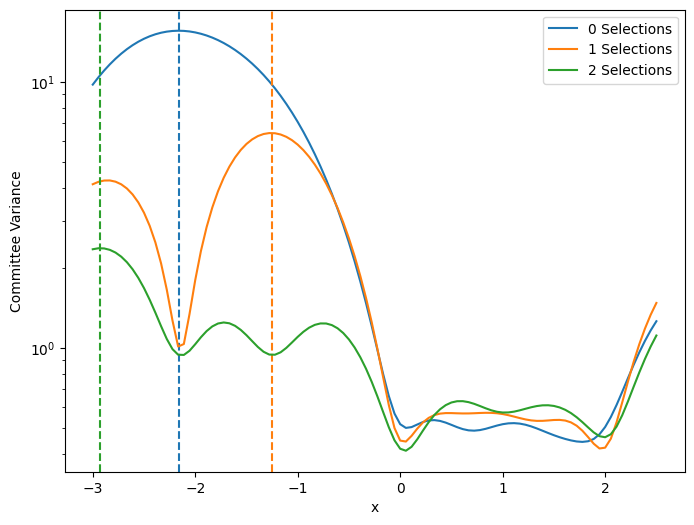

In [12]:

fig, ax = plt.subplots(1, figsize=(8, 6))

for i in range(max_selections+1):    
    ax.plot(x_ref, stds[i], color=f"C{i}", label=f"{i} Selections")
    ax.axvline(x_select[i], color=f"C{i}", linestyle="dashed")
ax.set_yscale("log")
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("Committee Variance")

We can see from the plot that updating the committee after each selection lowers the local committee standard deviation around that selection, and thus reduces the chance of oversampling in that region.